<a href="https://colab.research.google.com/github/Sakeena01/AI-Assisted-Threat-Detection-Dashboard/blob/main/python_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Create a basic pandas DataFrame from scratch with 3 columns: Name, Age, and City.

In [9]:
import pandas as pd

data = {
    "Name": ["Alice", "Bob", "Charlie", "Diana"],
    "Age": [25, 30, 35, 28],
    "City": ["New York", "Los Angeles", "Chicago", "Houston"]
}

df = pd.DataFrame(data)

print(df)


      Name  Age         City
0    Alice   25     New York
1      Bob   30  Los Angeles
2  Charlie   35      Chicago
3    Diana   28      Houston


Show me how to load a CSV file into a pandas DataFrame and display the first 5 rows.

In [10]:
import pandas as pd

df = pd.read_csv("sample.csv")   # replace "sample.csv" with your file path

print(df.head())


  CategoryColumn  NumericColumn
0              A           10.0
1              B           20.0
2              A            NaN
3              C           30.0
4              B            NaN


 Write a complete Python script using scikit-learn to train a Random Forest Classifier. Use a built-in dataset like Iris or Wine, split it 80/20 into train/test sets, scale the features using StandardScaler, train the model, and print a classification report along with a confusion matrix heatmap using seaborn.*italicized text*

📊 Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



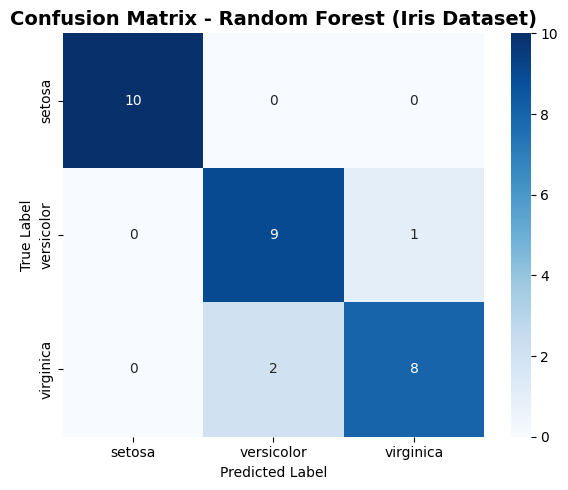

In [6]:
!pip install -q scikit-learn seaborn matplotlib pandas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris  # or load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix - Random Forest (Iris Dataset)", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


Write a Python script using pandas and matplotlib to load a sample CSV file, clean missing values by replacing them with the column mean, group the data by a categorical column, calculate the average of a numeric column, and plot the result as a styled horizontal bar chart.

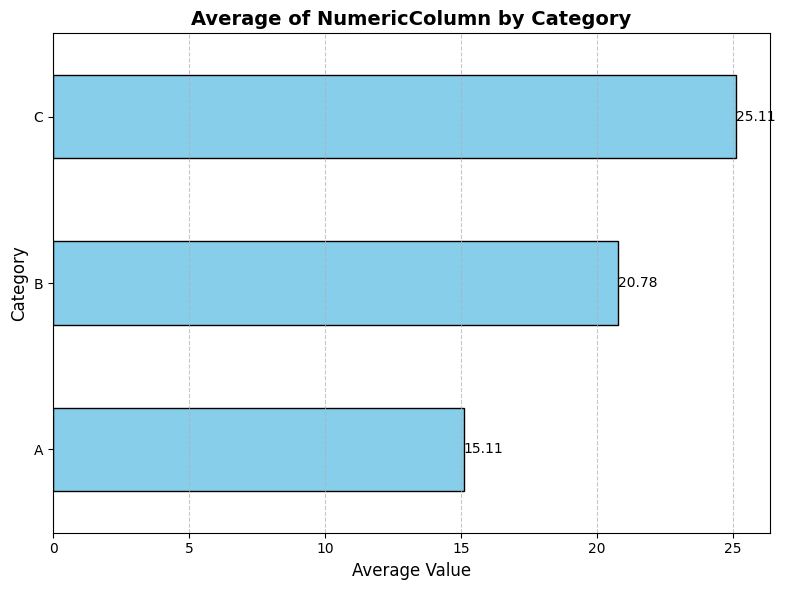

In [8]:
!pip install -q scikit-learn seaborn matplotlib pandas

import pandas as pd
import matplotlib.pyplot as plt

data = {
    "CategoryColumn": ["A", "B", "A", "C", "B", "C", "A", "B", "C"],
    "NumericColumn": [10, 20, None, 30, None, 25, 15, 22, None]
}
df_sample = pd.DataFrame(data)
df_sample.to_csv("sample.csv", index=False)

df = pd.read_csv("sample.csv")

df.fillna(df.mean(numeric_only=True), inplace=True)

grouped = df.groupby("CategoryColumn")["NumericColumn"].mean().sort_values()

plt.figure(figsize=(8, 6))
grouped.plot(kind="barh", color="skyblue", edgecolor="black")

plt.title("Average of NumericColumn by Category", fontsize=14, fontweight="bold")
plt.xlabel("Average Value", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

for index, value in enumerate(grouped):
    plt.text(value, index, f"{value:.2f}", va="center", ha="left", fontsize=10)

plt.tight_layout()
plt.show()
